# <u> **Job Postings Stakeholder Engagement or Orientation NLP Analysis** </u>

### **Practical Steps:**
- Collect job postings from platforms like Indeed or company career pages.
- Preprocess postings to extract stakeholder-related roles and terms.
- Apply KeyBERT to identify engagement keywords (e.g., “community engagement,” “employee inclusion”).
- Use sentiment analysis to evaluate the tone of engagement-related descriptions.
- Cluster postings to identify industry trends in stakeholder orientation.

### **Challenges:**
- Brief job postings limit depth of analysis.
- Non-standardized terminology complicates processing.
- Internal postings are often inaccessible.

### **Example:**
- A job posting for a “Community Engagement Specialist” might emphasize “building stakeholder relationships.” NLP can extract “stakeholder relationships,” classify the tone as positive, and correlate it with ESG performance.

### **About the Data:**
- https://www.kaggle.com/datasets/PromptCloudHQ/jobs-on-naukricom
- The dataset was found on Kaggle.com, and was created by PromptCloud.

---

## **Importing Packages:**

In [34]:
from MyPackages import *


---

## **Collect job postings from platforms like Indeed or company career pages:**

In [35]:
df = pd.read_csv(r"C:\BROCK U COURSE DOCS\DataSets\naukri_com-job_sample.csv")
df = df[['jobtitle', 'jobdescription']]
df

,jobtitle,jobdescription
0,Walkin Data Entry Operator (night Shift),Job Description Send me Jobs like this Quali...
1,Work Based Onhome Based Part Time.,Job Description Send me Jobs like this Quali...
2,Pl/sql Developer - SQL,Job Description Send me Jobs like this - as ...
3,Manager/ad/partner - Indirect Tax - CA,Job Description Send me Jobs like this - Inv...
4,JAVA Technical Lead (6-8 yrs) -,Job Description Send me Jobs like this Pleas...
...,...,...
21995,Quality Assurance - VP with Morgan Stanley Ban...,Job Description Send me Jobs like this Greet...
21996,Java Backend Developers for a Product Company,Job Description Send me Jobs like this Looki...
21997,Full Stack Development Engineer,Job Description Send me Jobs like this Work ...
21998,Sr UI Developer/ Technical Lead - Html/ CSS/ J...,Job Description Send me Jobs like this We ar...


## **Preprocess postings to extract stakeholder-related roles and terms:**

In [36]:
stakeholder_jobs = [
    'Stakeholder Relations Manager',
    'Stakeholder Engagement Manager',
    'Stakeholder Engagement Specialist',
    'Stakeholder Relations Specialist',
    'Stakeholder Engagement Coordinator',
    'Stakeholder Relations Coordinator',
    'Stakeholder Engagement Officer',
    'Stakeholder Relations Officer',
    'Stakeholder Affairs Manager',
    'Stakeholder Affairs Specialist',
    'Stakeholder Communications Manager',
    'Stakeholder Communications Specialist',
    'Stakeholder Partnerships Manager',
    'Stakeholder Partnerships Specialist',
    'Stakeholder Experience Manager',
    'Stakeholder Experience Specialist',
    'Investor Relations Analyst',
    'Investor Relations Associate',
    'Investor Relations Manager',
    'Investor Relations Specialist',
    'Investor Relations Officer',
    'Shareholder Relations Manager',
    'Shareholder Relations Specialist',
    'Shareholder Services Representative',
    'Corporate Relations Manager',
    'Corporate Affairs Manager',
    'Corporate Affairs Specialist',
    'Corporate Communications Manager',
    'Corporate Communications Specialist',
    'External Relations Manager',
    'External Relations Specialist',
    'Business Analyst',
    'Business Relationship Manager',
    'Project Manager',
    'Project Coordinator',
    'Program Manager',
    'Program Coordinator',
    'Product Manager',
    'Product Owner',
    'Project Analyst',
    'Program Analyst',
    'Management Consultant',
    'Strategy Analyst',
    'Strategy Consultant',
    'Change Management Consultant',
    'Change Management Specialist',
    'Implementation Manager',
    'Implementation Specialist',
    'Account Manager',
    'Client Relationship Manager',
    'Client Services Manager',
    'Customer Success Manager',
    'Government Relations Analyst',
    'Government Relations Manager',
    'Government Affairs Specialist',
    'Government Affairs Manager',
    'Public Affairs Specialist',
    'Public Affairs Manager',
    'Public Relations Specialist',
    'Public Relations Manager',
    'Community Relations Specialist',
    'Community Engagement Specialist',
    'Community Engagement Manager',
    'Public Engagement Officer',
    'Public Consultation Specialist',
    'Policy Analyst',
    'Public Policy Analyst',
    'Regulatory Affairs Specialist',
    'Regulatory Affairs Manager',
    'External Affairs Specialist',
    'External Affairs Manager',
    'ESG Analyst',
    'ESG Manager',
    'ESG Specialist',
    'Sustainability Analyst',
    'Sustainability Manager',
    'Sustainability Specialist',
    'Sustainability Consultant',
    'Corporate Responsibility Manager',
    'Corporate Social Responsibility Specialist',
    'Social Impact Analyst',
    'Social Impact Manager',
    'Sustainability Reporting Analyst',
    'ESG Reporting Specialist',
    'ESG Reporting Manager',
    'Responsible Investment Analyst',
    'Sustainability Engagement Manager'
]

> This is a list of stakeholder related job positions. The dataframe will be filtered to only show references of these listed jobs. All other jobs will be filtered out as a result.
>
> NOTE: This list was generated by ChatGPT.

In [37]:
df = df[df['jobtitle'].isin(stakeholder_jobs)]
df

,jobtitle,jobdescription
62,Product Manager,Job Description Send me Jobs like this Job D...
513,Business Analyst,Job Description Send me Jobs like this Requi...
876,Program Manager,"Job Description Send me Jobs like this ""Job ..."
989,Project Manager,Job Description Send me Jobs like this Scope...
1346,Program Coordinator,Job Description Send me Jobs like this Job D...
...,...,...
21020,Product Manager,Job Description Send me Jobs like this Posit...
21368,Project Coordinator,Job Description Send me Jobs like this This ...
21590,Business Analyst,Job Description Send me Jobs like this Raam ...
21620,Business Analyst,Job Description Send me Jobs like this Gathe...


> This is the new and complete job dataset which only includes stakeholder related job positions. This dataset will now be used in the analyses.

In [38]:
df = df.reset_index()
df = df.drop(labels= 'index', axis= 1)

## **Apply KeyBERT to identify engagement keywords (e.g., “community engagement,” “employee inclusion”):**

In [39]:
model = KeyBERT()
keywords = model.extract_keywords(df['jobdescription'].tolist())

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

> The model KeyBERT is used to extract the keywords from each line of text in the dataset.

In [40]:
keyword0 = []
keyword1 = []
keyword2 = []
keyword3 = []
keyword4 = []

for i in range(len(keywords)):
    keyword0.append(keywords[i][0][0])
    keyword1.append(keywords[i][1][0])
    keyword2.append(keywords[i][2][0])
    keyword3.append(keywords[i][3][0])
    keyword4.append(keywords[i][4][0])

df['Keyword 0'] = keyword0
df['Keyword 1'] = keyword1
df['Keyword 2'] = keyword2
df['Keyword 3'] = keyword3
df['Keyword 4'] = keyword4

df

,jobtitle,jobdescription,Keyword 0,Keyword 1,Keyword 2,Keyword 3,Keyword 4
0,Product Manager,Job Description Send me Jobs like this Job D...,skills,ecommerce,jobs,role,analytics
1,Business Analyst,Job Description Send me Jobs like this Requi...,analyst,mba,jobs,requirements,postgraduate
2,Program Manager,"Job Description Send me Jobs like this ""Job ...",recruitment,bangalore,jobs,recruiter,dotnet
3,Project Manager,Job Description Send me Jobs like this Scope...,recruitment,hiring,hiringexcellent,management,managing
4,Program Coordinator,Job Description Send me Jobs like this Job D...,hiring,ambassadors,recruiter,jobs,coordinator
...,...,...,...,...,...,...,...
162,Product Manager,Job Description Send me Jobs like this Posit...,requirements,skills,experience,mba,management
163,Project Coordinator,Job Description Send me Jobs like this This ...,hyderabad,responsibilities,management,planning,milestones
164,Business Analyst,Job Description Send me Jobs like this Raam ...,raam,management,careers,roles,role
165,Business Analyst,Job Description Send me Jobs like this Gathe...,consulting,development,developer,requirements,application


> The keywords are then taken and added into the dataframe. There are a total of 5 keywords for each job description. Some of these keywords represent job skills like analyst, management, and ecommerce, while others are simply random keywords like job, application, and mba. engagement keywords must identified and taken out.

In [41]:
engagement_words = [
    'stakeholder',
    'stakeholders',
    'engagement',
    'engaged',
    'community',
    'communities',
    'outreach',
    'involvement',
    'participation',
    'consultation',
    'liaison',
    'advocacy',
    'advocate',
    'employee',
    'employees',
    'workforce',
    'staff',
    'colleagues',
    'inclusion',
    'belonging',
    'diversity',
    'equity',
    'participation',
    'empowerment',
    'relationship',
    'relationships',
    'relations',
    'rapport',
    'networking',
    'coordination',
    'cooperation',
    'collaboration',
    'partnership',
    'partnerships',
    'alliance',
    'alliances',
    'communication',
    'communications',
    'communicate',
    'communicating',
    'consultation',
    'dialogue',
    'interaction',
    'interactions',
    'feedback',
    'listening',
    'information-sharing',
    'correspondence',
    'customer',
    'customers',
    'client',
    'clients',
    'consumer',
    'consumers',
    'member',
    'members',
    'user',
    'users',
    'customer-facing',
    'client-facing',
    'shareholder',
    'shareholders',
    'investor',
    'investors',
    'investment',
    'shareholder-facing',
    'public',
    'public-facing',
    'government',
    'governmental',
    'regulatory',
    'regulator',
    'regulators',
    'policymaker',
    'policymakers',
    'officials',
    'citizens',
    'external',
    'internal',
    'external-facing',
    'internal-facing',
    'affairs',
    'relations',
    'social',
    'responsibility',
    'sustainability',
    'sustainable',
    'ESG',
    'ethical',
    'ethics',
    'impact',
    'social-impact',
    'corporate-responsibility',
    'CSR',
    'event',
    'events',
    'meeting',
    'meetings',
    'workshop',
    'workshops',
    'forum',
    'forums',
    'roundtable',
    'roundtables',
    'campaign',
    'campaigns',
    'program',
    'programs',
    'initiative',
    'initiatives',
    'management',
    'coordination',
    'facilitation',
    'negotiation',
    'negotiating',
    'relationship-building',
    'network',
    'networks',
    'engage',
    'engaging',
    'support',
    'represent',
    'representation',
    'liaison'
]

> These are the stakeholder engagement keywords that must be identified from all the keyword columns. The keywords not apart of this list will be filtered out.
>
> NOTE: This list was generated by ChatGPT.

In [42]:
keywords = pd.concat([df['Keyword 0'], df['Keyword 1'], df['Keyword 2'], df['Keyword 3'], df['Keyword 4']])

keywords = keywords.reset_index()
keywords = keywords.drop(labels= 'index', axis= 1)

keywords['words'] = keywords[0]
keywords = keywords.drop(labels= 0, axis= 1)

keywords

,words
0,skills
1,analyst
2,recruitment
3,recruitment
4,hiring
...,...
830,management
831,milestones
832,role
833,application


> Created a single column dataframe by concatenating, or combining all the columns of keywords.

In [43]:
keywords = keywords[keywords['words'].isin(engagement_words)]
keywords

,words
22,management
29,clients
72,management
83,clients
93,partnerships
...,...
799,management
810,management
811,stakeholders
817,management


> From the list provided by ChatGPT, there has been a total of 66 keywords identified as stakeholder engagement keywords. This includes keywords across all 5 keyword columns for each job description. Note that the first column of keywords contain the most important and significant ones, which are able to describe the entire line of job description text.

In [44]:
counts = keywords['words'].value_counts().reset_index()
counts

,words,count
0,management,49
1,customers,5
2,stakeholders,4
3,clients,3
4,client,2
5,partnerships,1
6,responsibility,1
7,partnership,1


In [45]:
keywords['words'].value_counts(normalize= True).reset_index()

,words,proportion
0,management,0.742424
1,customers,0.075758
2,stakeholders,0.060606
3,clients,0.045455
4,client,0.030303
5,partnerships,0.015152
6,responsibility,0.015152
7,partnership,0.015152


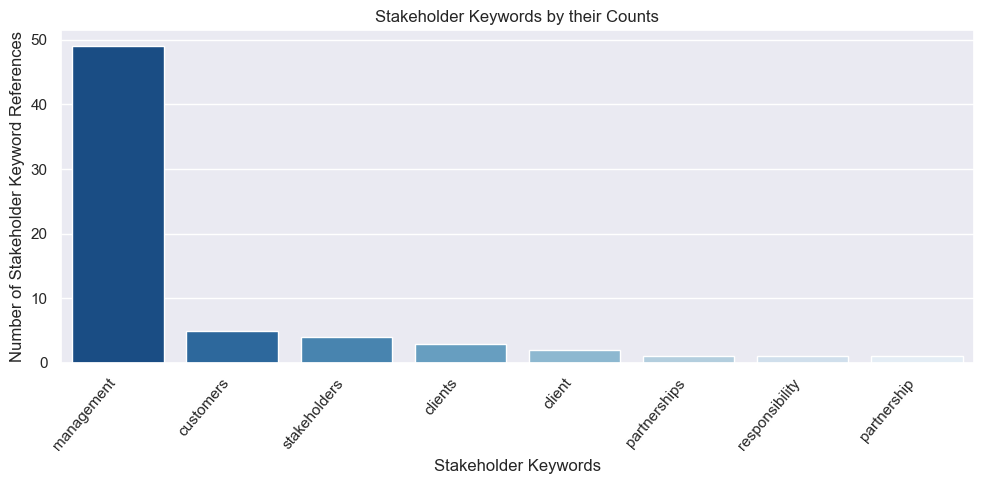

In [46]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'words', y= 'count', palette= 'Blues_r')
plt.title('Stakeholder Keywords by their Counts')
plt.xlabel('Stakeholder Keywords')
plt.xticks(rotation= 50, ha= 'right')
plt.ylabel('Number of Stakeholder Keyword References')

plt.tight_layout()
plt.show()

> By far the most frequently referenced stakeholder engagement related keyword from all 5 keywords generated for each job description is "management", with a total number of references at 49. Customers is second, and it is significantly lower at 5, followed by stakeholders with a count of 4. Management makes up 74% of the stakeholder engagement keywords, customers is only 7.6%, while stakeholders is only 6.1%.

## **Use sentiment analysis to evaluate the tone of engagement-related descriptions:**

In [47]:
df['jobdescription'] = df['jobdescription'].str.replace(r'Job Description\s*\xa0\s*Send me Jobs like this ', '', regex=True)

> The problem with FinBERT is that it has a limit of the amount of tokens it assigns each line of text in a dataframe. Each job description is well beyond that limit, and so if we add the data to FinBERT as is, the lines of text will be truncated, which means when the limit is reached, the line of text will be cut and the second half will not be included in the sentiment analysis. That is why we must edit the data and split it ourselves.

In [48]:
desc = df['jobdescription'].str.split('.')
desc.tolist()

[['Job Description PlaySimple Games is looking for Product Managers to own, ship & run mobile games at rocket speed',
  ' Its a fast-paced, high-adrenaline job, with plenty to learn and build',
  ' If you enjoy crunching numbers, are never satisfied with the products around you, and would relish a new challenge every day, youll love this job',
  " Salary: Not Disclosed by Recruiter Industry: Internet / Ecommerce Functional Area: IT Software - Mobile Role Category:Programming & Design Role:Product Manager Keyskills Product Manager Product management Desired Candidate Profile What we're looking forNo excuse leadership \xa0Extremely passionate about their work - all in \xa0Quite simply, were looking for smart, creative product people who can drive results quickly, at high quality",
  ' \xa0Strong analytical skills, and an ability to tease out actionable insights from data, are a given',
  '\xa0Had a leadership role at a company \xa0Ability to balance multiple projects, deadlines, and resp

> First, the job description must be split based on the periods in the sentence. We store it in a temporary variable called desc, which is short for job description.

In [49]:
jobs = df['jobtitle'].tolist()
desc = desc.tolist()

joblst = []
desclst = []

for i in range(len(jobs)):
    for k in range(len(desc[i])):
        joblst.append(jobs[i])
        desclst.append(desc[i][k])

df_for_finbert = {
    'Job Title': joblst,
    'Job Description': desclst
}

df_for_finbert = pd.DataFrame(df_for_finbert)
df_for_finbert

,Job Title,Job Description
0,Product Manager,Job Description PlaySimple Games is looking fo...
1,Product Manager,"Its a fast-paced, high-adrenaline job, with p..."
2,Product Manager,"If you enjoy crunching numbers, are never sat..."
3,Product Manager,Salary: Not Disclosed by Recruiter Industry: ...
4,Product Manager,"Strong analytical skills, and an ability to ..."
...,...,...
2744,Product Manager,Salary: Not Disclosed by Recruiter Industry: ...
2745,Product Manager,- Ability to manage all aspects of product de...
2746,Product Manager,- Ability to define & own your own product ad...
2747,Product Manager,- B2C product management experience in a star...


> Then a for loop is created to take the job title names and apply them to each split sentence of the job description. We then combine all the job titles and their corresponding job descriptions into one single dataframe for sentiment analysis using FinBERT.

In [50]:
df_for_finbert = df_for_finbert[df_for_finbert['Job Description'].str.len() >= 50]

df_for_finbert = df_for_finbert.reset_index()
df_for_finbert = df_for_finbert.drop(labels= 'index', axis= 1)

> The FinBERT dataset is then cleaned up to remove any very small lines of text. Ones which would be labeled as neutral since they do not provide any useful or meaningful information for the model to analyze.

In [51]:
finbertOutput = finbert(df_for_finbert['Job Description'].tolist())
finbertOutput = pd.DataFrame(finbertOutput)

df_for_finbert = pd.merge(df_for_finbert, finbertOutput, left_index= True, right_index= True)

df_for_finbert

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

,Job Title,Job Description,label,score
0,Product Manager,Job Description PlaySimple Games is looking fo...,neutral,0.923131
1,Product Manager,"Its a fast-paced, high-adrenaline job, with p...",neutral,0.900838
2,Product Manager,"If you enjoy crunching numbers, are never sat...",neutral,0.876157
3,Product Manager,Salary: Not Disclosed by Recruiter Industry: ...,neutral,0.833297
4,Product Manager,"Strong analytical skills, and an ability to ...",positive,0.759464
...,...,...,...,...
1789,Product Manager,We are looking for awesome PMs with demonstra...,positive,0.633872
1790,Product Manager,Salary: Not Disclosed by Recruiter Industry: ...,neutral,0.825728
1791,Product Manager,- Ability to manage all aspects of product de...,neutral,0.884910
1792,Product Manager,- Ability to define & own your own product ad...,positive,0.676117


> The FinBERT model has analyzed the split lines of text of the job descriptions for each job title and output a sentiment label (positive, negative, or neutral) and also an accuracy score (from 0 to 1).

In [52]:
counts = df_for_finbert['label'].value_counts().reset_index()
counts

,label,count
0,neutral,1518
1,positive,256
2,negative,20


In [53]:
df_for_finbert['label'].value_counts(normalize= True).reset_index()

,label,proportion
0,neutral,0.846154
1,positive,0.142698
2,negative,0.011148


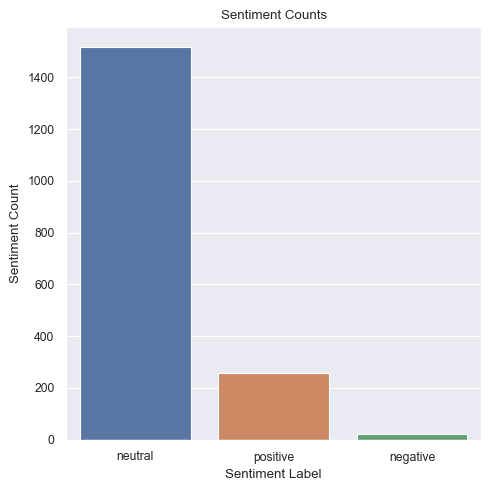

In [54]:
sns.set_theme('paper')
plt.figure(figsize= (5, 5))

sns.barplot(data= counts, x= 'label', y= 'count', hue= 'label')
plt.title('Sentiment Counts')
plt.xlabel('Sentiment Label')
plt.ylabel('Sentiment Count')

plt.tight_layout()
plt.show()

> The graph along with the two tables above show that the sentiment label with the highest number of references in the FinBERT dataframe is neutrality, with a count of 1518, making up 85% of the lines of text. Positive job description sentences comes in at second highest, making up 14.3% of the sentences at a count of 256. Negative job descriptions are the lowest, with only 20 sentences having a negative sentiment, making up only 1.12%.

In [55]:
counts = df_for_finbert[['Job Title', 'label']].value_counts().reset_index()
counts

,Job Title,label,count
0,Project Manager,neutral,624
1,Business Analyst,neutral,263
2,Program Manager,neutral,257
3,Product Manager,neutral,191
4,Account Manager,neutral,121
5,Project Manager,positive,94
6,Business Analyst,positive,59
7,Product Manager,positive,42
8,Project Coordinator,neutral,40
9,Program Manager,positive,26


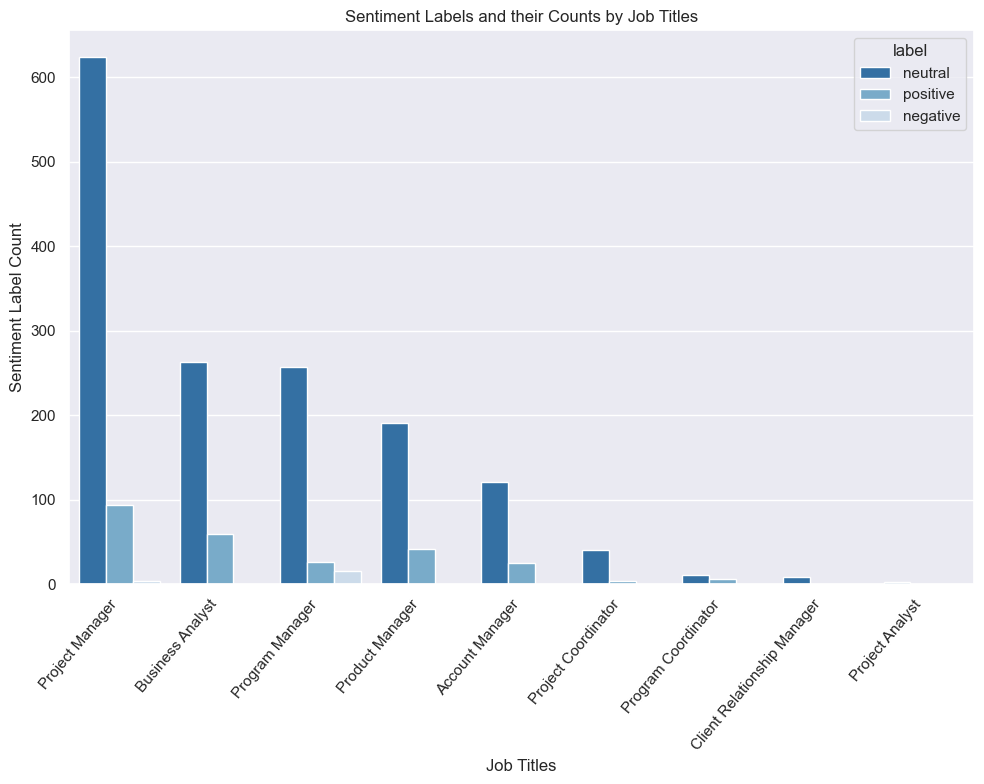

In [56]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 8))

sns.barplot(data= counts, x= 'Job Title', y= 'count', hue= 'label', palette='Blues_r')
plt.title('Sentiment Labels and their Counts by Job Titles')
plt.xlabel('Job Titles')
plt.xticks(rotation= 50, ha= 'right')
plt.ylabel('Sentiment Label Count')

plt.tight_layout()
plt.show()

> This graph and the table above shows a different way of breaking down counts of sentiments. The graph depicts sentiments and their counts by each individual job title. You can see positive, negative, and neutral sentiment job description sentences for each job. Project Manager has the highest number of neutral sentiments at 624, as well as the highest number of positive sentences at 94. The negative sentiment sentences come in at 4, and this job is only one of two jobs with negative sentiment job description sentences. The other is Project Manager, with a count of 16 negatively viewed sentences.

## **Cluster postings to identify industry trends in stakeholder orientation:**

In [57]:
vector = tf_idf(stop_words= 'english')
transformed = vector.fit_transform(df['jobdescription'].tolist())

> In order to perform k-Means Cluster analysis, each word in the lines of text for the job descriptions must be represented as numeric values based on their importance level, which is determined through the TF-IDF model.

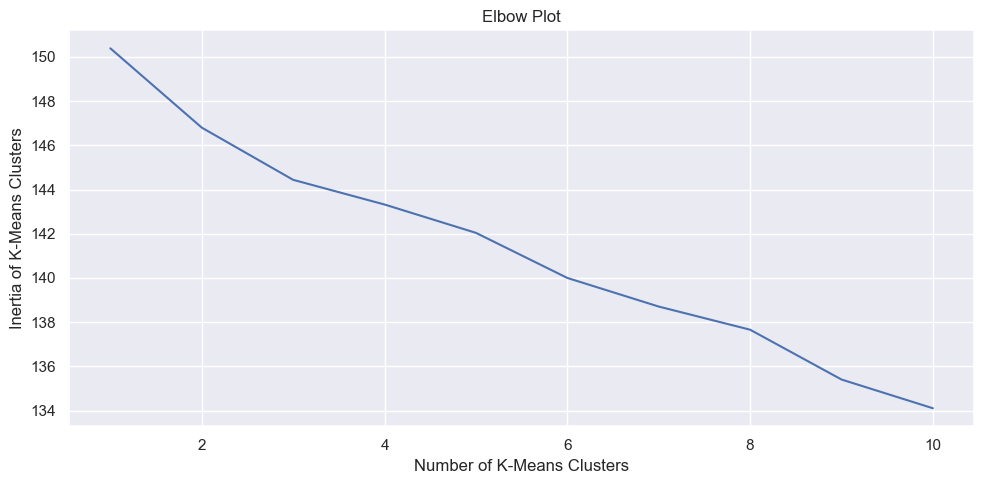

In [58]:
lstClusters = []
lstInertia = []

for i in range(1, 11):
    model = KMeans(n_clusters= i, random_state= 42).fit(transformed)
    lstClusters.append(i)
    lstInertia.append(model.inertia_)

sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.lineplot(x= lstClusters, y= lstInertia)
plt.title('Elbow Plot')
plt.xlabel('Number of K-Means Clusters')
plt.ylabel('Inertia of K-Means Clusters')

plt.tight_layout()
plt.show()

> The second step to performing K-Means Clustering is that the number of optimal clusters must be determined using an elbow plot. This graph is very heard to tell which number of clusters is optimal for this model, so we will choose 3.

In [59]:
model = KMeans(n_clusters= 3, random_state= 42).fit(transformed)

clusters = model.labels_
df['clusters'] = clusters
df

,jobtitle,jobdescription,Keyword 0,Keyword 1,Keyword 2,Keyword 3,Keyword 4,clusters
0,Product Manager,Job Description PlaySimple Games is looking fo...,skills,ecommerce,jobs,role,analytics,2
1,Business Analyst,Requirements Analysis & translation and simpli...,analyst,mba,jobs,requirements,postgraduate,0
2,Program Manager,"""Job Description Dear Candidate Greetings from...",recruitment,bangalore,jobs,recruiter,dotnet,1
3,Project Manager,"Scope of Role: To manage and develop Business,...",recruitment,hiring,hiringexcellent,management,managing,2
4,Program Coordinator,Job Description Hiring of Ambassadors from Bes...,hiring,ambassadors,recruiter,jobs,coordinator,1
...,...,...,...,...,...,...,...,...
162,Product Manager,Position : Product Manager Reporting to : AVP ...,requirements,skills,experience,mba,management,2
163,Project Coordinator,This opening is for our Corporate Office at La...,hyderabad,responsibilities,management,planning,milestones,1
164,Business Analyst,Raam Group is a 500 Cr organization with inter...,raam,management,careers,roles,role,1
165,Business Analyst,"Gather business requirements, analyze and comm...",consulting,development,developer,requirements,application,0


> The K-Means Cluster model has been created, and has grouped each record of the dataframe into one of three clusters, which has been chosen based on their job descriptions. We will use the job titles to determine what each cluster represents.

In [60]:
df['clusters'].value_counts().reset_index()

,clusters,count
0,1,72
1,2,61
2,0,34


> From this table, the cluster containing the highest number of job postings is labeled as 1, which is the second cluster. It has a count of 72 job postings. The second is cluster 2, which is the third cluster, and the cluster with the lowest number of job postings is the first one labeled as cluster 0, containg a total of 34 postings.

In [61]:
counts = df[df['clusters'] == 0]['jobtitle'].value_counts().reset_index()
counts

,jobtitle,count
0,Business Analyst,22
1,Project Manager,5
2,Program Manager,4
3,Account Manager,2
4,Product Manager,1


> The first cluster (cluster 0) can be classified as business analyst and administrative job positions. The reason for this is that the job position with the highest number of references within the cluster is business analyst. The rest are all manager jobs such as project manager, program manager, account manager, and lastly product manager.

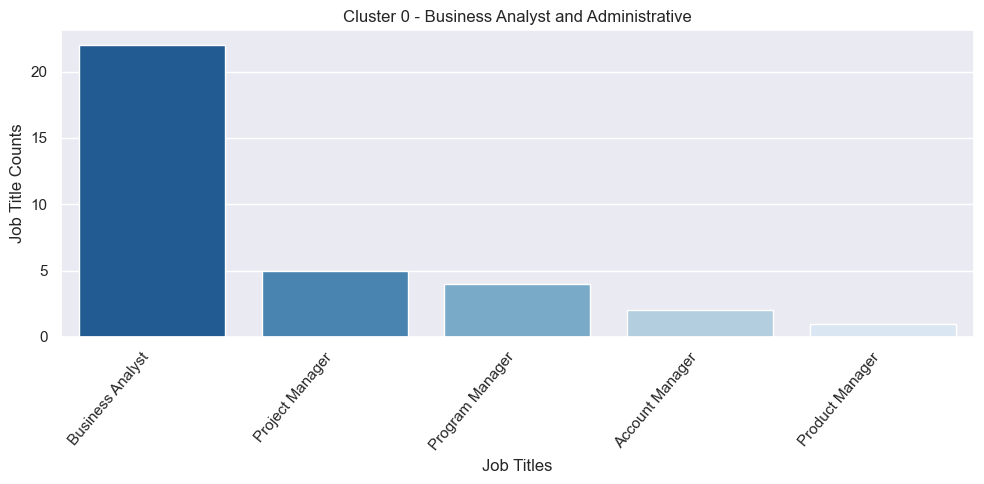

In [62]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'jobtitle', y= 'count', palette='Blues_r')
plt.title('Cluster 0 - Business Analyst and Administrative')
plt.xlabel('Job Titles')
plt.xticks(rotation= 50, ha= 'right')
plt.ylabel('Job Title Counts')

plt.tight_layout()
plt.show()

> 

In [63]:
counts = df[df['clusters'] == 1]['jobtitle'].value_counts().reset_index()
counts

,jobtitle,count
0,Project Manager,58
1,Program Manager,6
2,Project Coordinator,3
3,Business Analyst,2
4,Program Coordinator,1
5,Project Analyst,1
6,Client Relationship Manager,1


> The second cluster (cluster 1) can be classified as Project/Program Managerial job positions. The reason for this is that the job position with the highest number of references within the cluster is project manager, with a count of 58. The second highest, with a count of 6 is program manager, and the rest are an assortment of coordinator and analyst positions.

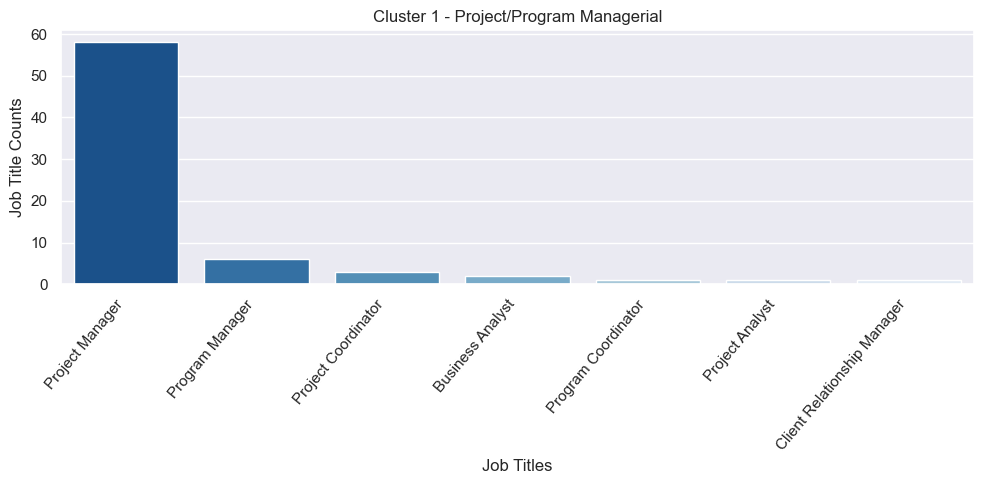

In [64]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'jobtitle', y= 'count', palette='Blues_r')
plt.title('Cluster 1 - Project/Program Managerial')
plt.xlabel('Job Titles')
plt.xticks(rotation= 50, ha= 'right')
plt.ylabel('Job Title Counts')

plt.tight_layout()
plt.show()

In [65]:
counts = df[df['clusters'] == 2]['jobtitle'].value_counts().reset_index()
counts

,jobtitle,count
0,Product Manager,24
1,Account Manager,17
2,Business Analyst,10
3,Program Manager,4
4,Project Manager,4
5,Project Coordinator,1
6,Program Coordinator,1


> The third and final cluster (cluster 2) can be classified as Product and Account Managerial and Analysis job positions. The reason is that the job position with the highest number of references in the cluster is Product manager, with a count of 24. The second highest, with a count of 17 is account manager, and the third is business analyst with 10 references.

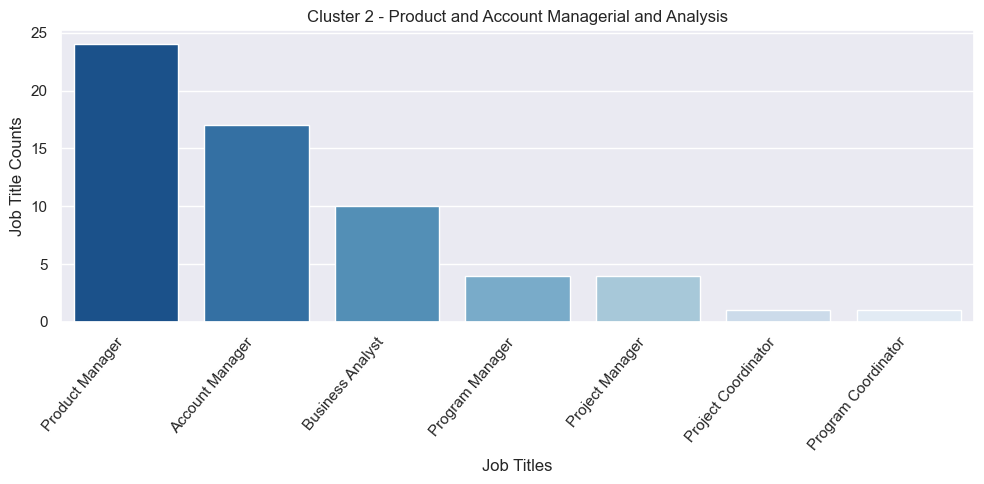

In [66]:
sns.set_theme('notebook')
plt.figure(figsize= (10, 5))

sns.barplot(data= counts, x= 'jobtitle', y= 'count', palette='Blues_r')
plt.title('Cluster 2 - Product and Account Managerial and Analysis')
plt.xlabel('Job Titles')
plt.xticks(rotation= 50, ha= 'right')
plt.ylabel('Job Title Counts')

plt.tight_layout()
plt.show()

> 

> 